## Diákok klaszterezése

### Történet
Egy középiskolában a tanárok szeretnék jobban megérteni a diákok teljesítményét és fizikai jellemzőit.  
Minden sor az **egyik diákot** jelenti, és négy tulajdonságot tartalmaz:

- **math_score**: a diák matematika pontszáma (0–100)  
- **english_score**: a diák angol pontszáma (0–100)  
- **height_cm**: a diák testmagassága centiméterben  
- **weight_kg**: a diák testtömege kilogrammban  

## Feladat 1 – Adatok beolvasása

Olvasd be a `students_clustering_data.csv` fájlt pandas-szal, és nézd meg az első néhány sort.  

In [1]:
# -------------------------
# Megoldás: Feladat 1 – Adatok beolvasása
# -------------------------
import pandas as pd

# CSV beolvasása
df = pd.read_csv('students_clustering_data.csv')

# Az első pár sor megtekintése
print(df.head())

# Az oszlopok ellenőrzése
print(df.columns)

   math_score  english_score   height_cm  weight_kg
0   54.043483      68.282768  174.564326  71.179139
1   57.278086      65.554613  173.589186  62.956747
2   50.601478      87.572194  162.671474  61.457790
3   75.092457      77.310517  148.071582  47.599090
4   60.291044      59.285149  159.488007  59.743068
Index(['math_score', 'english_score', 'height_cm', 'weight_kg'], dtype='object')


## Feladat 2 – Adatok vizualizálása

Vizualizáld a diákokat scatter ploton (`math_score` vs `english_score`).  

**Tippek:**  
- Használhatod a `matplotlib.pyplot.scatter()` függvényt.  
- Érdemes beállítani a **méretet (`s`)** és az **átlátszóságot (`alpha`)**, hogy a sűrűbb területek jól látszódjanak.  
- Mindig érdemes a tengelyeket feliratozni (`xlabel`, `ylabel`) és címet adni a diagramnak (`title`).

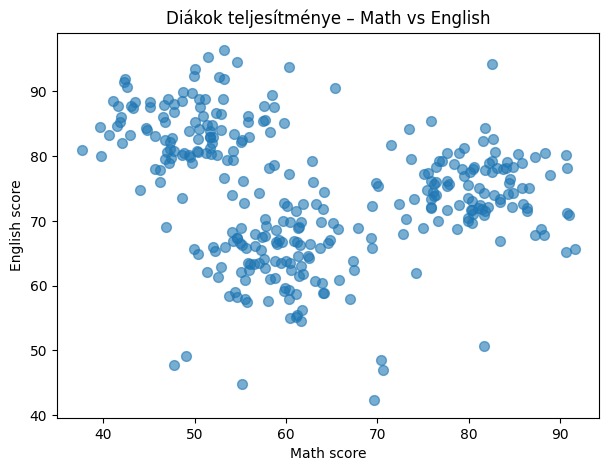

In [2]:
# -------------------------
# Megoldás: Feladat 2 – Adatok vizualizálása
# -------------------------
import matplotlib.pyplot as plt

# Scatter plot a diákok jegyeiről
plt.figure(figsize=(7,5))
plt.scatter(df['math_score'], df['english_score'], s=50, alpha=0.6)
plt.title("Diákok teljesítménye – Math vs English")
plt.xlabel("Math score")
plt.ylabel("English score")
plt.show()

## Feladat 3 – DBSCAN futtatása

Tanítsd be a DBSCAN algoritmust a diákok jegyein (`math_score` és `english_score`).  

- Kísérletezz a paraméterekkel: `eps` és `min_samples`.  
- Tipp: Az optimális értékek **3 és 7 között** lehetnek.  
- Figyeld meg, hogyan változik a klaszterek száma és a zajpontok aránya a különböző beállításoknál.  

**Megjegyzés:**  
- Ne adj meg fix értékeket, próbálj ki több kombinációt a fenti tartományban.  
- Jegyezd fel, mely paraméterek mellett kapod a legértelmesebb klaszterezést.

Klaszterek száma: 3
Zajpontok száma: 45


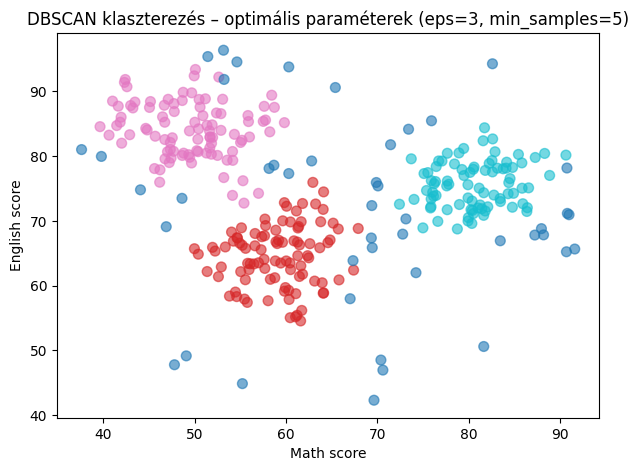

In [3]:
# -------------------------
# Megoldás: Feladat 3 – DBSCAN optimális paraméterekkel
# -------------------------
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X_scores = df[['math_score', 'english_score']]

# DBSCAN optimális paraméterekkel
dbscan = DBSCAN(eps=3, min_samples=5)
labels = dbscan.fit_predict(X_scores)

# Klaszterek és zajpontok száma
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Klaszterek száma: {n_clusters}")
print(f"Zajpontok száma: {n_noise}")

# Vizualizáció
plt.figure(figsize=(7,5))
plt.scatter(X_scores['math_score'], X_scores['english_score'], c=labels, s=50, alpha=0.6, cmap='tab10')
plt.title(f"DBSCAN klaszterezés – optimális paraméterek (eps=3, min_samples=5)")
plt.xlabel("Math score")
plt.ylabel("English score")
plt.show()

## Feladat 4 – Hierarchikus klaszterezés a fizikai jellemzők alapján

### Feladat lépések

**1. lépés – Adatok kiválasztása**  
Válaszd ki a `height_cm` és `weight_kg` oszlopokat, és tárold egy új változóban, például `X_hw`.

*Megjegyzés:* Így könnyen kezelhető lesz az adathalmaz a klaszterezéshez.

**2. lépés – Linkage mátrix készítése**  
Hozd létre a linkage mátrixot a `linkage()` függvénnyel, `method='ward'` használatával.

*Megjegyzés:* A linkage mátrix tartalmazza, hogyan egyesülnek a pontok klaszterekké, és mennyi a közöttük lévő távolság.

**3. lépés – Dendrogram rajzolása**  
Készíts dendrogramot (`scipy.cluster.hierarchy.dendrogram()`) a linkage mátrixból, hogy vizuálisan is lásd a klaszterezés szerkezetét.

*Megjegyzés:* A dendrogram segít kiválasztani a klaszterek számát, és jól látható a klaszterek hierarchiája.

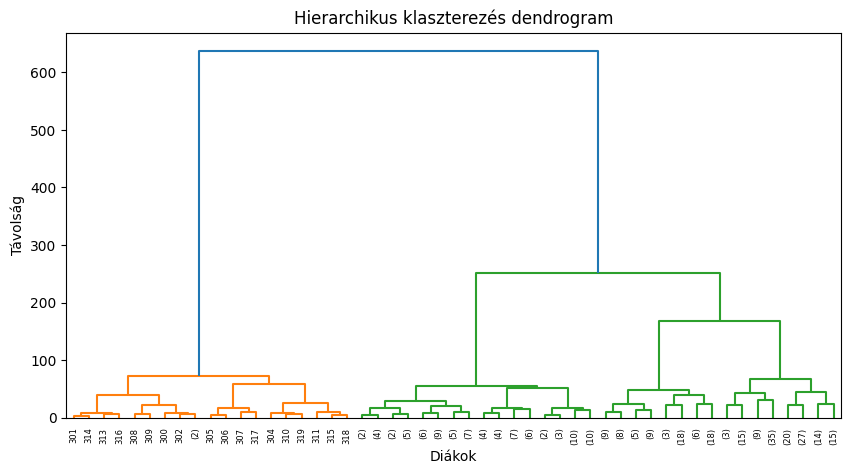

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram,fcluster
import matplotlib.pyplot as plt

# Adatok kiválasztása
X_hw = df[['height_cm', 'weight_kg']]

# Linkage mátrix készítése (Ward módszer)
Z = linkage(X_hw, method='ward')

# Dendrogram megjelenítése
plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='level', p=5)  # csak a legfelső ágak
plt.title("Hierarchikus klaszterezés dendrogram")
plt.xlabel("Diákok")
plt.ylabel("Távolság")
plt.show()

## Feladat 5 – Klaszterek létrehozása és vizualizálása

Most hozzuk létre a tényleges klasztereket, és szemléltessük a fizikai jellemzők szerint.

### Feladat lépések

**1. lépés – Klaszterek létrehozása**  
Válaszd ki a klaszterek számát (például 4), és hozd létre a klasztercímkéket az `fcluster()` segítségével.

**2. lépés – Vizualizáció**  
Rajzold ki a klasztereket scatter ploton (`height_cm` vs `weight_kg`), minden klaszterhez külön színt használva.

*Megjegyzés:*  
- A scatter plot segítségével könnyen látható, hogy a diákok hogyan csoportosulnak fizikai jellemzőik alapján.  
- A klaszterek száma és elhelyezkedése a dendrogram alapján logikusan választható.

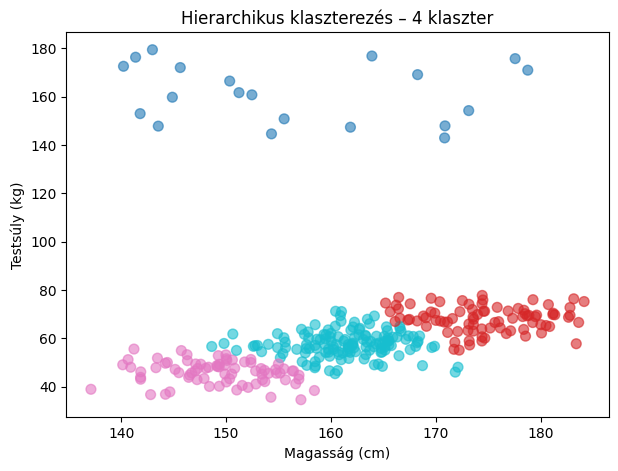

In [5]:
# 1. lépés – Klaszterek létrehozása (példa: 4 klaszter)
max_clusters = 4
labels_hw = fcluster(Z, max_clusters, criterion='maxclust')

# 2. lépés – Scatter plot vizualizáció
plt.figure(figsize=(7,5))
plt.scatter(X_hw['height_cm'], X_hw['weight_kg'], c=labels_hw, s=50, alpha=0.6, cmap='tab10')
plt.title(f"Hierarchikus klaszterezés – {max_clusters} klaszter")
plt.xlabel("Magasság (cm)")
plt.ylabel("Testsúly (kg)")
plt.show()